In [ ]:
import torch
import os

def load_txt_as_ground_truth(txt_path):
    boxes = []
    labels = []

    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x1, y1, x2, y2 = map(float, parts)
                labels.append(int(cls))
                boxes.append([x1, y1, x2, y2])

    if boxes:
        return {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }
    else:
        # Return empty tensors if no annotations or file doesn't exist
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64)
        }


# Paths
image_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/images"
label_dir_voc = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/label_aa_pascal_voc"
output_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/output_1"

image_filenames = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith('.tif')
])

gt_targets = []

for img_file in image_filenames:
    base_name = os.path.splitext(img_file)[0]
    txt_file = os.path.join(label_dir_voc, base_name + ".txt")
    gt = load_txt_as_ground_truth(txt_file)
    gt_targets.append(gt)

In [106]:
print(gt_targets)

[{'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}, {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}

In [107]:
def load_txt_as_prediction(txt_path):
    boxes = []
    labels = []
    scores = []

    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 6:
                    continue
                cls, conf, x1, y1, x2, y2 = map(float, parts)
                labels.append(int(cls))
                scores.append(conf)
                boxes.append([x1, y1, x2, y2])

    if boxes:
        return {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "scores": torch.tensor(scores, dtype=torch.float32)
        }
    else:
        # Return empty prediction if no data
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
            "scores": torch.zeros((0,), dtype=torch.float32)
        }

In [108]:
# prediction_dir = "/home/umang.shikarvar/Final/lucknow_predictions"

predictions = []

for img_file in image_filenames:
    base_name = os.path.splitext(img_file)[0]
    pred_file = os.path.join(output_dir, base_name + ".txt")
    pred = load_txt_as_prediction(pred_file)
    predictions.append(pred)

In [109]:
def make_class_agnostic(detection_list):
    """
    Sets all labels in each detection dict to class 0
    """
    for d in detection_list:
        d["labels"] = torch.zeros_like(d["labels"])
    return detection_list

In [110]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Class-agnostic conversion
gt_targets_ca = make_class_agnostic(gt_targets)
predictions_ca = make_class_agnostic(predictions)

# Compute mAP
metric = MeanAveragePrecision()
metric.update(predictions_ca, gt_targets_ca)
results = metric.compute()

print("Class-Agnostic mAP@0.50:", results["map_50"].item())

Class-Agnostic mAP@0.50: 0.035365309566259384


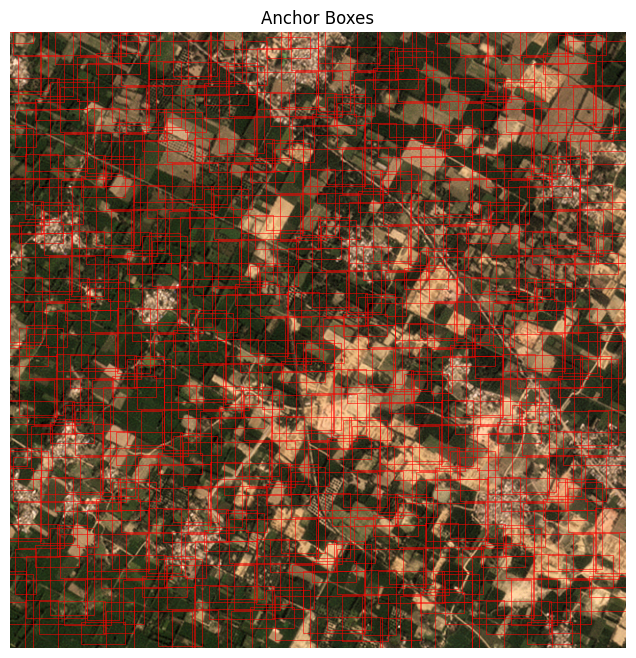

In [111]:
import torch
import matplotlib.pyplot as plt
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision import transforms

import torch
import matplotlib.pyplot as plt
from torchvision.models.detection.image_list import ImageList
from torchvision.models.detection.rpn import AnchorGenerator

def visualize_anchors_on_image(anchor_generator, image_tensor, feature_map_shape=(40, 40), stride=16):
    """
    Visualizes RPN anchors over a given input image.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    ax.imshow(image_np)

    # Step 1: Wrap in ImageList
    image_list = ImageList(image_tensor.unsqueeze(0), [(image_tensor.shape[1], image_tensor.shape[2])])  # (H, W)

    # Step 2: Create dummy feature maps
    feature_map = [torch.zeros(1, 1, *feature_map_shape)]

    # Step 3: Generate anchors
    anchors = anchor_generator(image_list, feature_map)[0]  # (N_anchors, 4)
    anchors = anchors.cpu().detach()

    # Step 4: Plot subset of anchors
    for i in range(0, len(anchors), len(anchors) // 500 + 1):
        x1, y1, x2, y2 = anchors[i]
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='red', linewidth=0.4)
        ax.add_patch(rect)

    ax.set_title("Anchor Boxes")
    ax.axis("off")
    plt.show()

# Example usage
from torchvision.transforms import functional as F
from PIL import Image

# Load image and preprocess
img = Image.open("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/images/8985633_3140642.tif").convert("RGB")
transform = transforms.Compose([
    transforms.ToTensor()
])
img_tensor = transform(img)

# Define small-object-focused anchor generator
anchor_generator = AnchorGenerator(
    sizes=((32, 48, 64),),           # scales that cover smaller regions
    aspect_ratios=((0.5, 1.0, 2.0),)        # handle tall/square/wide objects
)

# Visualize anchors
visualize_anchors_on_image(anchor_generator, img_tensor, feature_map_shape=(40, 40), stride=16)
